# Business Analytics of Amazon Customer Reviews****

import packages or functions

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import json #to read java format file
import seaborn as sns #packages to be installed
import numpy as np #array processing
import os
import nltk #tokenization
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import gzip, json, itertools
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
df = pd.read_csv("/kaggle/input/amazon-customer-review/Amazon_review_data.csv") #read and save the data in a dataframe

**view first 5 rows in the dataframe or table**

In [3]:
df.head(5) #view the first 5 rows in the table

,Unnamed: 0,asin,overall,summary,reviewText
0,0,0143026860,1.0,One Star,great
1,1,0143026860,4.0,... to reading about the Negro Baseball and th...,My husband wanted to reading about the Negro ...
2,2,0143026860,4.0,Worth the Read,"This book was very informative, covering all a..."
3,3,0143026860,5.0,Good Read,I am already a baseball fan and knew a bit abo...
4,4,0143026860,5.0,"More than facts, a good story read!",This was a good story of the Black leagues. I ...


names of columns in the amazon table 

In [4]:
df.columns #list the names of columns in the table

Index(['Unnamed: 0', 'asin', 'overall', 'summary', 'reviewText'], dtype='object')

# **Data Cleaning**# 

1. drop unwanted column(s)

In [5]:
df = df.drop(df.columns[0], axis = 1) #drop the first columns containing only index number

In [6]:
df.columns

Index(['asin', 'overall', 'summary', 'reviewText'], dtype='object')

* rename the overall column to ratings which represent customer ratings
* rename the asin column to product_id

In [7]:
df.rename(columns = {"overall":"ratings"}, inplace = True)#rename the overall column to ratings which represent customer ratings
df.rename(columns ={'asin':'product_id'}, inplace =True) #rename asin to product_id
df.columns #check if the columns is still there

Index(['product_id', 'ratings', 'summary', 'reviewText'], dtype='object')

2. Check for rows with missing values

In [8]:
number_of_null_Reviews = df['reviewText'].isnull().sum()
print(f"the total number of rows with zero reviews in the review column is: {number_of_null_Reviews}" )

number_of_empty_rows_in_rating_column = df['ratings'].isnull().sum()
print(f"the total number of empty ratings is: {number_of_empty_rows_in_rating_column}")

the total number of rows with zero reviews in the review column is: 10
the total number of empty ratings is: 0


we have 10 rows with no review from customers but all purchased products have been rated. Thus, we drop empty rows from the review columns; this will increase our sentiment analysis accuracy.

In [9]:
#drop empty rows
df = df.dropna(subset =['ratings', 'reviewText']) #drop empty rows


In [10]:
#make sure that table maintained its structure and empty rows are cleaned
number_of_empty_rows = df["reviewText"].isnull().sum()
print(f"number of empty rows is:{number_of_empty_rows}")
df.head(3)

number of empty rows is:0


,product_id,ratings,summary,reviewText
0,0143026860,1.0,One Star,great
1,0143026860,4.0,... to reading about the Negro Baseball and th...,My husband wanted to reading about the Negro ...
2,0143026860,4.0,Worth the Read,"This book was very informative, covering all a..."


next we'll remove duplicates product_id

In [11]:
number_of_duplicates = df.duplicated(subset =['product_id']).sum() #check for duplicates
print(f"the of duplicates are: {number_of_duplicates}")

the of duplicates are: 338365


In [12]:
df.drop_duplicates(subset = ['product_id'], inplace = True) #drop d

finding the number of unique products

In [13]:
number_of_unique_products = df['product_id'].nunique()
print(f"there {number_of_unique_products} number of unique products")

there 32571 number of unique products


check for basic information about the data using descriptive statistics

In [14]:
df.head(5)

,product_id,ratings,summary,reviewText
0,0143026860,1.0,One Star,great
7,014789302X,1.0,One Star,I didn't like this product it smudged all unde...
17,0992916305,5.0,Gorgeous!,"LOVE, LOVE, LOVE!! The movie was breathtaking ..."
23,1620213982,5.0,cute!,The product was cute and easy to use. It arri...
4802,162209798X,5.0,Square one for living well,As an aspiring actor and singer and too infreq...


In [15]:
print(df['ratings'].describe())

count    32571.000000
mean         4.014062
std          1.446663
min          1.000000
25%          3.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: ratings, dtype: float64


there are 32571 unique products in the beauty category with a mean rating of 4, stan dev. of 1.4, min of 1 and max rating of 5 from customers

copy and save a copy of the clean data

In [16]:
selected_products = df.copy()
selected_products.head(2)

,product_id,ratings,summary,reviewText
0,0143026860,1.0,One Star,great
7,014789302X,1.0,One Star,I didn't like this product it smudged all unde...


In [17]:
import nltk
nltk.download('punkt') #downloading required package to fun LLM


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for res in ['stopwords', 'punkt', 'wordnet','omw-1.4']: #packages to download
  try:
    nltk.data.find(f"corpora/{res}" if res != 'punkt' else f"tokenize/{res}")
  except LookupError:
    nltk.download(res, quiet=True)

extend = {
    "use","used","using","one","get","got","make","made","buy","bought","thing",
    "good","great","well","nice","really","still","little","bit","dont","didnt",
    "product","device","item","unit","year","time","also","ive", 'doesnt', "doesn't ", 'even'} #tokens to be cleaned or eliminated because they do not add meaning to the review sentiment

stopwords =  set(stopwords.words("english")) | extend #terms/tokens to be removed from the list of terms/token in the review
lemmatizer = WordNetLemmatizer() #convert the terms to their root

def clean_review(text):
  if not isinstance(text, str): #check for empty strings/reviews
    return " "

  text = text.lower()
  text = re.sub(r"<[^>]+>", " ", text)   # Remove HTML tags (e.g., <br>, <div>, etc.) from the tex
  text = re.sub(r"http\S+|www\.\S+", " ", text)  #remove web links  (e.g., http://example.com or www.example.com)
  text = "".join(ch for ch in text if ch.isalnum() or ch.isspace())   #Keep only alphanumeric characters and spaces; remove punctuation and special symbols
  toks = [lemmatizer.lemmatize(w) for w in text.split()]
  toks = [w for w in toks if w not in stopwords and len(w) > 2]
  return " ".join(toks) #remove unwanted characters and words to increase accuracy of classification

In [19]:
selected_products["cleaned_reviewText"] = selected_products['reviewText'].apply(clean_review)##apply the cleaning function on all the rows in reviewText
#added a new column containg the cleaned text or review without stopwords
selected_products.head(2)

,product_id,ratings,summary,reviewText,cleaned_reviewText
0,0143026860,1.0,One Star,great,
7,014789302X,1.0,One Star,I didn't like this product it smudged all unde...,like smudged eye throughly day


In [20]:
print(f"the cleaned table has {selected_products.shape} dimension") 

# 32571 rows and 5 columns

the cleaned table has (32571, 5) dimension


**EDA FOR THE ALL-BEAUTY CATEGORY**# 

visual representation of the sentiment ratings of purchases by customer

In [21]:
def sentiment(x):
    if x > 3:
        return 'Positive' #posive review if rating is >3
    elif x <3:
        return "Negative" #Negative review if ratings is <3
    elif x == 3:
        return "Neutral" #customers are neutral if rating is 3
    else:
        return "no rating" # when no rating is given
        
#create a new column containing sentiment categories
selected_products["Review_Sentiment"] = selected_products["ratings"].apply(sentiment)
        
selected_products.head(2)  #preview the new column

,product_id,ratings,summary,reviewText,cleaned_reviewText,Review_Sentiment
0,0143026860,1.0,One Star,great,,Negative
7,014789302X,1.0,One Star,I didn't like this product it smudged all unde...,like smudged eye throughly day,Negative


here the ratings are categorize into >3 as positive, =3 as neutral and <3 as negative is added a new columns called Review_Sentiment. This ratings will be combined with other factors to determine the sellability or otherwise of a product.

In [22]:
selected_products['Review_Sentiment'].value_counts(normalize= True)*100  
#calculate and displays the proportion of the total sentiment as percent

Review_Sentiment
Positive    72.721132
Negative    19.050689
Neutral      8.228178
Name: proportion, dtype: float64

more of the review are positive compared to neutral or negative as indicated by the table above. for instance, 64% of the ratings are postive while 25% is negative. this is an indication that more than 50% of product sells are considered positive.

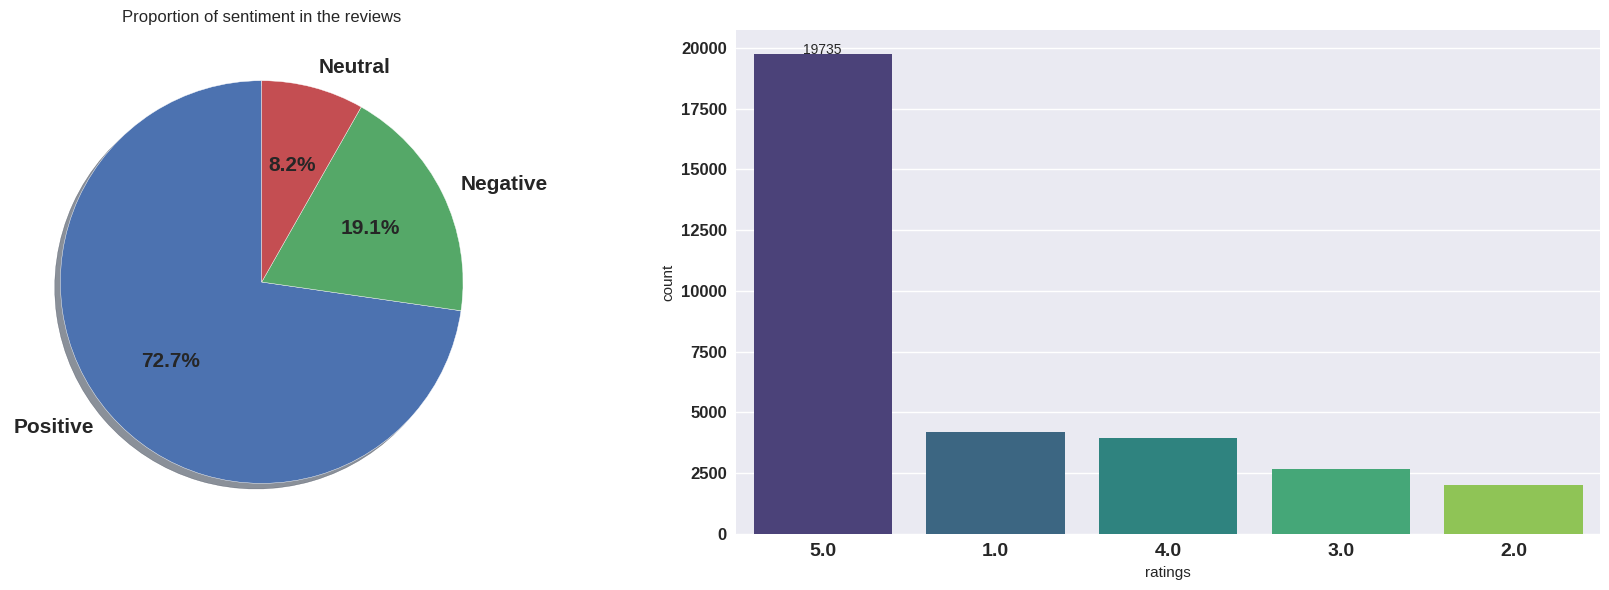

<Figure size 800x550 with 0 Axes>

<Figure size 800x550 with 0 Axes>

<Figure size 800x550 with 0 Axes>

<Figure size 800x550 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8")

sentiment_counts = selected_products['Review_Sentiment'].value_counts() #assign the proportion to sentiment_count
fig, ax = plt.subplots(1,2, figsize =(18,6)) #Creates a figure with 1 row and 2 columns of subplots
ax[0].pie(
    sentiment_counts,
    labels = sentiment_counts.index,  #add label to each slice
    autopct = "%1.1f%%",  #Displays the percentage values on each slice with
    startangle = 90,  #rotate the pie so the first slice starts at angle 90
    shadow = True, #Adds a shadow effect under the pie chart for visual depth.
    #hue = sentiment_counts.index,
    wedgeprops ={'edgecolor': 'white'}, #set pie edge color as white
    textprops ={'fontsize':15, 'fontweight':'bold'} #create pie chat to show the representation of each sentiment category
)
ax[0].set_title(f"Proportion of sentiment in the reviews") #add a title to the pie chat

sns.countplot( #create a countplot
  data = selected_products, #data source
  x  ='ratings',   #we are using the overall ratings column
  order = selected_products['ratings'].value_counts().index, #sum the total count for each rating and add the label
  palette  ="viridis",
  ax=ax[1]
)
ax[1].tick_params(axis='x', labelsize=14, width=2)  #increases the tick label size
ax[1].tick_params(axis='y', labelsize=14, width=2)
for tick in ax[1].get_xticklabels(): #get the tick labels from the table for the x axis
  tick.set_fontsize(14) #set the tick font size
  tick.set_fontweight('bold') #bolden the font

for tick in ax[1].get_yticklabels(): #get tick labels from the table for the y axis
  tick.set_fontsize(12)
  tick.set_fontweight('bold')

for i, p in enumerate(ax[1].patches):
  ax[1].annotate(
      selected_products['ratings'].value_counts().iloc[i],
      (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
      ha = "center"
  )      #add the total count on each bar and center it

  plt.tight_layout()
  plt.show()

figure A and B indicates that positive ratings dominate the selected products. buyers with 5 rating are highre than lower value ratings. indicating satisfaction with the purchased products compared with the opposite.

Bag of words (BOW) Representatio for the Reviews and Confusion Matrix Classification of Sentiment/Ratings

In [24]:
#BOW Representatin for the Reviews
import nltk
from nltk import word_tokenize #importing tokenizer

X = selected_products['cleaned_reviewText'] # other columns to learn from
Y = selected_products['Review_Sentiment']   #target

tokenize_reviews = [] #create an empty list or container
for each in X.str.lower(): #loop thru the list of terms after converting them to lower letters
  tokenize_reviews.append(nltk.word_tokenize(each))  #store the tokenize terms in a list
tokenize_reviews[:2] #view the first set of tokenize terms from the first few review

[[], ['like', 'smudged', 'eye', 'throughly', 'day']]

tokenization using BOW seprate the terms in the review into tokens that can used to underr customer sentiment. the [[], ['like', 'smudged', 'eye', 'throughly', 'day']] indicates the terms used by the customer to describe how they feel regading their purchase

usg snowball stemmar to convert tokens to their root

In [25]:
from nltk.stem import SnowballStemmer   #stemmer package to be used
s_stemmer = SnowballStemmer('english') #initialize the stemmer
s_stemmed_list = [] #create a list to store the final stemmed words
for each_list in tokenize_reviews: #loop thru the tokenize terms from the result above
  line = []  #create an empty list
  for word in each_list:    #loop through the list
    line.append(s_stemmer.stem(word)) #using the snowball stemmer to reduce the words to their root. this helps in decreasing the dimension or number of tokens in the list.
  s_stemmed_list.append(line) #store stemmed token

s_stemmed_list[:2]

[[], ['like', 'smudg', 'eye', 'through', 'day']]